## Nigeria Climate Data Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("../data/nigeria.csv")

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,25.23,29.25,22.06,7.19,0.0,68.26,1.73,2.61,100.86,13.36
1,2015,2,26.16,29.41,22.87,6.54,0.0,73.23,1.42,1.95,100.94,15.37
2,2015,3,25.66,29.02,22.63,6.39,0.0,78.71,1.69,2.33,101.06,15.98
3,2015,4,24.11,27.27,19.92,7.35,0.0,63.66,2.15,3.80,101.09,11.65
4,2015,5,23.40,27.28,18.18,9.10,0.0,59.45,1.88,3.48,101.03,10.40


## Data Cleaning
- Replace -999 with NaN
- Remove duplicates
- Handle missing values

In [3]:
df.replace(-999, np.nan, inplace=True)
df.drop_duplicates(inplace=True)
df.ffill(inplace=True)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,25.23,29.25,22.06,7.19,0.00,68.26,1.73,2.61,100.86,13.36
1,2015,2,26.16,29.41,22.87,6.54,0.00,73.23,1.42,1.95,100.94,15.37
2,2015,3,25.66,29.02,22.63,6.39,0.00,78.71,1.69,2.33,101.06,15.98
3,2015,4,24.11,27.27,19.92,7.35,0.00,63.66,2.15,3.80,101.09,11.65
4,2015,5,23.40,27.28,18.18,9.10,0.00,59.45,1.88,3.48,101.03,10.40
...,...,...,...,...,...,...,...,...,...,...,...,...
4103,2026,86,29.05,32.43,26.69,5.74,2.82,76.60,2.35,3.39,100.58,19.10
4104,2026,87,28.72,31.98,27.14,4.84,5.19,79.61,2.55,3.17,100.64,19.49
4105,2026,88,27.72,29.53,26.21,3.32,1.43,82.83,1.10,1.78,100.61,19.22
4106,2026,89,28.42,31.17,26.36,4.81,0.85,77.73,2.30,3.40,100.53,18.73


In [4]:
(df.isna().sum() / len(df)) * 100

YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
dtype: float64

In [5]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000
mean,2020.131451,180.121227,26.656928,28.914667,24.886461,4.028206,4.213914,85.237040,2.217135,2.903335,100.827205,18.558505
std,3.248907,106.294767,1.123335,1.294345,1.396727,1.399169,7.266742,5.446007,0.587191,0.696885,0.165321,1.646313
min,2015.000000,1.000000,21.120000,25.260000,15.170000,1.160000,0.000000,54.400000,0.740000,1.290000,100.380000,9.430000
25%,2017.000000,86.000000,25.720000,27.920000,24.100000,3.090000,0.330000,83.930000,1.770000,2.370000,100.710000,17.970000
50%,2020.000000,179.000000,26.820000,28.990000,25.100000,3.770000,1.840000,86.350000,2.200000,2.810000,100.820000,18.840000
75%,2023.000000,272.000000,27.540000,29.910000,25.860000,4.600000,5.200000,88.500000,2.630000,3.390000,100.950000,19.570000
max,2026.000000,366.000000,29.290000,32.880000,27.790000,11.730000,166.100000,93.790000,4.780000,6.000000,101.350000,21.740000


## Outlier Detection

In [6]:
cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

z_scores = (df[cols] - df[cols].mean()) / df[cols].std()
z_scores = z_scores.abs()

outliers = (z_scores > 3)

outlier_counts = outliers.sum()
print(outlier_counts)

total_outliers = outliers.any(axis=1).sum()
print("Total rows with outliers:", total_outliers)

T2M             10
T2M_MAX          1
T2M_MIN         68
PRECTOTCORR     75
RH2M           128
WS2M             5
WS2M_MAX        10
dtype: int64
Total rows with outliers: 225


## Outlier Detection
Outliers were identified using the Z-score method with a threshold of |Z| > 3.

The results show that PRECTOTCORR (precipitation) has the highest number of outliers (95), followed by T2M_MIN (18) and RH2M (13). Other variables such as temperature (T2M), wind speed (WS2M, WS2M_MAX), and maximum temperature (T2M_MAX) show relatively few or no extreme values.

In total, 132 rows contain at least one outlier across the selected variables.

These outliers are likely to represent real extreme weather events (such as heavy rainfall or unusually low temperatures) rather than data errors. Therefore, they were retained in the dataset to preserve important climate variability and extreme event information.

## Temperature Trend

In [7]:
df["Date"] = pd.to_datetime(df["YEAR"].astype(str) + "-" + df["DOY"].astype(str), format="%Y-%j")
df["Month"] = df["Date"].dt.month

<Axes: xlabel='Month'>

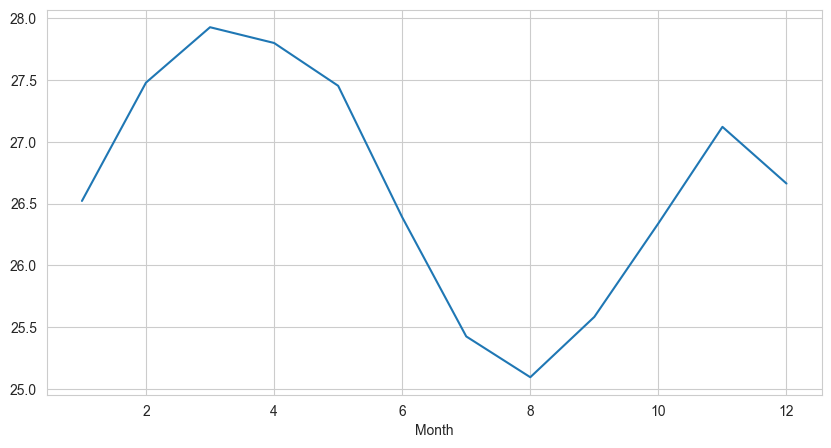

In [8]:
monthly_temp = df.groupby("Month")["T2M"].mean()
monthly_temp.plot(figsize=(10,5))

## Rainfall Trend

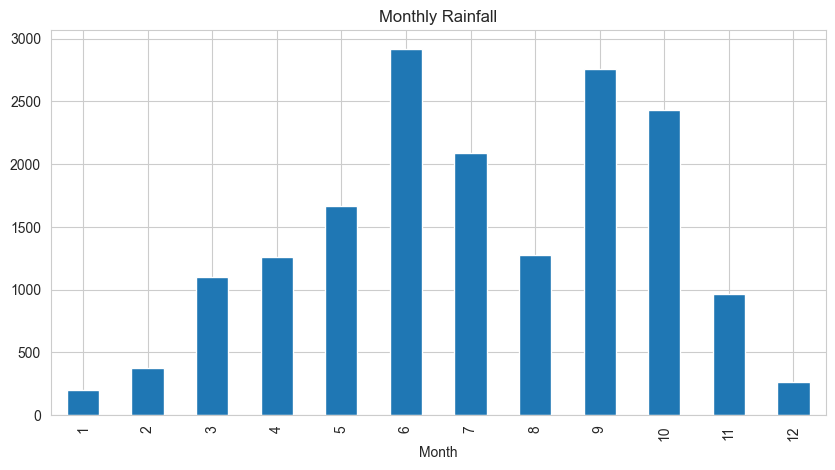

In [9]:
monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()

monthly_rain.plot(kind="bar", figsize=(10,5), title="Monthly Rainfall")
plt.show()

## Corelation Analysis

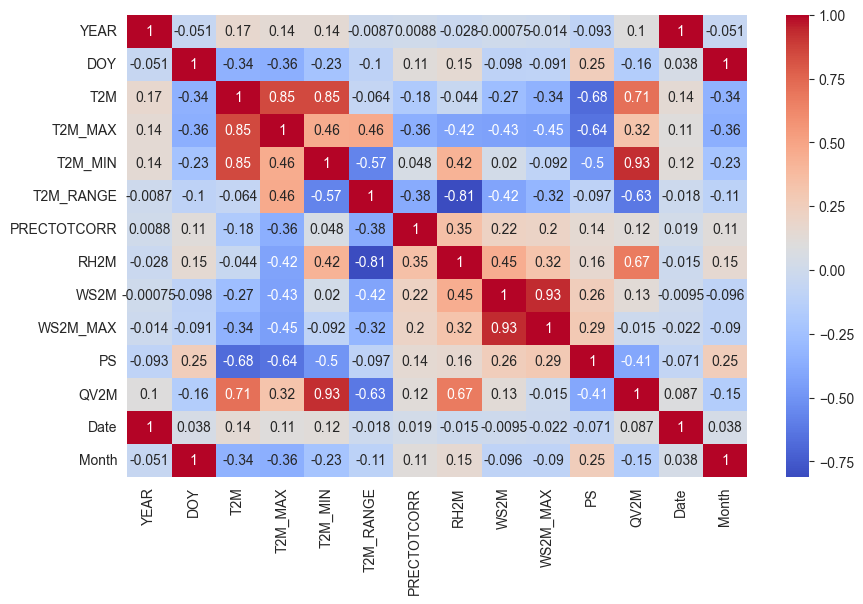

In [10]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

## Distribution Analysis

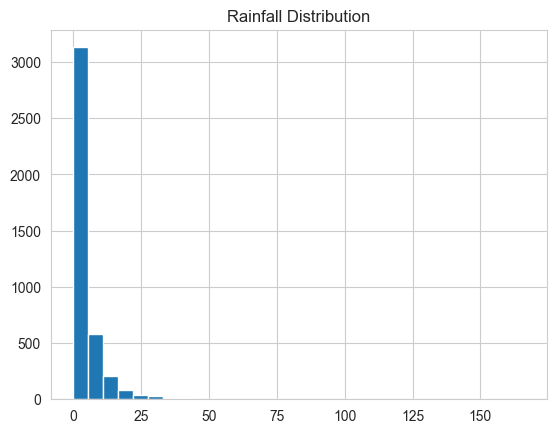

In [11]:
df["PRECTOTCORR"].hist(bins=30)
plt.title("Rainfall Distribution")
plt.show()

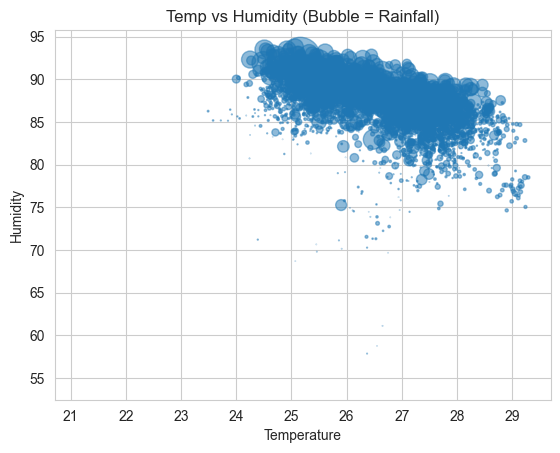

In [12]:
plt.scatter(df["T2M"], df["RH2M"], s=df["PRECTOTCORR"]*5, alpha=0.5)
plt.xlabel("Temperature")
plt.ylabel("Humidity")
plt.title("Temp vs Humidity (Bubble = Rainfall)")
plt.show()

## 🌍 Overview
The dataset contains daily climate data for Nigeria including temperature, rainfall, humidity, wind speed, pressure, and water vapor.

## 🌡️ Temperature
* Average temperatures range between 23°C and 26°C
* Maximum temperatures reach about 29°C
* Daily temperature variation is moderate (6°C–9°C)

📌 Nigeria has a warm tropical climate with relatively stable temperatures.

## 🌧️ Rainfall
* Precipitation values are 0.0 in the sample period

📌 Indicates a dry spell or low rainfall period.

## 💧 Humidity
* Relative humidity ranges from 59% to 78%

📌 Shows a humid tropical environment, typical of coastal and rainforest regions.

## 🌬️ Wind & Pressure
* Wind speed is low to moderate (1.4–2.1 m/s)
* Atmospheric pressure is stable (~100.8–101.1 kPa)

📌 Weather conditions are stable with no extreme events.

## 🧠 Conclusion
Nigeria shows a warm, humid, and stable tropical climate with consistent temperatures, high humidity, and low wind activity during the observed period.


In [14]:
df.to_csv("../data/nigeria_clean.csv", index=False)